In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from vitpol import ViT
import time
import torch.nn.functional as F

# def print_p_values(model):
#     print("\n=== p VALUES (per head) ===")
#     for name, module in model.named_modules():
#         if hasattr(module, "p_raw"):
#             p = 1 + F.softplus(module.p_raw)
#             print(f"{name}: {p.detach().cpu().numpy()}")


def print_p_values(model):
    print("\n=== p VALUES (per head) ===")
    for name, module in model.named_modules():
        if hasattr(module, "p_raw"):
            p = module.p_raw 
            print(f"{name}: {p.detach().cpu().numpy()}")
            
def main():

    model = ViT(
        img_size=224,
        patch_size=16,
        num_classes=10,
        in_channels=3,
        dim=384,
        depth=7,
        heads=6
    )

    print(model)

    batch_size = 32

    # Нормализация ImageNet
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # Аугментации для train 
    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # ← ЗАПЯТАЯ!
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        normalize
    ])

    # Для test/val
    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='train',
        size='320px',
        download=False,
        transform=transform_train
    )

    test_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='val',
        size='320px',
        download=False,
        transform=transform_test
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    def train_epoch(model, loader, optimizer, criterion, device):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    def test_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    # Настройки цикла
    epochs = 50
    test_accs = []
    epoch_times = [] 
    best_test_loss = float('inf')

    # EARLY STOPPING
    patience = 7
    epochs_no_improve = 0

    log_file = open("training_log.txt", "w", encoding="utf-8")

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
        scheduler.step()
        
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        
        test_accs.append(test_acc)

        # Подготовка строки лога
        log_str = (f"Epoch {epoch + 1}/{epochs} | "
                   f"Time: {epoch_duration:.2f}s | "
                   f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                   f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}\n")
        
        print(log_str, end="")
        log_file.write(log_str)
        log_file.flush()

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_vit_model.pth')
            print(f"---> New best model saved! Loss: {test_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement: {epochs_no_improve}/{patience}")

        # === EARLY STOPPING ===
        if epochs_no_improve >= patience:
            print(f"\n Early stopping at epoch {epoch+1}")
            break

        # if (epoch + 1) % 10 == 0:
            # torch.save(model.state_dict(), f'vit_epoch_{epoch+1}.pth')

    # Итоговая статистика
    avg_time = sum(epoch_times) / len(epoch_times)
    total_time = sum(epoch_times)
    
    summary_str = (f"\n{'='*30}\n"
                   f"Training Complete!\n"
                   f"Total Time: {total_time:.2f}s ({total_time/60:.2f} min)\n"
                   f"Average Time per Epoch: {avg_time:.2f}s\n"
                   f"Best Test Accuracy: {max(test_accs):.4f}\n"
                   f"{'='*30}")
    
    print(summary_str)
    log_file.write(summary_str + "\n")
    log_file.close()
    
    print("\nFINAL p VALUES:")
    print_p_values(model)

if __name__ == "__main__":
    main()

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from vitpol import ViT
import time
import torch.nn.functional as F

# def print_p_values(model):
#     print("\n=== p VALUES (per head) ===")
#     for name, module in model.named_modules():
#         if hasattr(module, "p_raw"):
#             p = 1 + F.softplus(module.p_raw)
#             print(f"{name}: {p.detach().cpu().numpy()}")


def print_p_values(model):
    print("\n=== p VALUES (per head) ===")
    for name, module in model.named_modules():
        if hasattr(module, "p_raw"):
            p = module.p_raw 
            print(f"{name}: {p.detach().cpu().numpy()}")
            
def main():

    model = ViT(
        img_size=224,
        patch_size=16,
        num_classes=10,
        in_channels=3,
        dim=384,
        depth=7,
        heads=6
    )

    print(model)

    batch_size = 32

    # Нормализация ImageNet
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # Аугментации для train 
    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # ← ЗАПЯТАЯ!
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        normalize
    ])

    # Для test/val
    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='train',
        size='320px',
        download=False,
        transform=transform_train
    )

    test_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='val',
        size='320px',
        download=False,
        transform=transform_test
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    def train_epoch(model, loader, optimizer, criterion, device):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    def test_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    # Настройки цикла
    epochs = 50
    test_accs = []
    epoch_times = [] 
    best_test_loss = float('inf')

    # EARLY STOPPING
    patience = 7
    epochs_no_improve = 0

    log_file = open("training_log.txt", "w", encoding="utf-8")

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
        scheduler.step()
        
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        
        test_accs.append(test_acc)

        # Подготовка строки лога
        log_str = (f"Epoch {epoch + 1}/{epochs} | "
                   f"Time: {epoch_duration:.2f}s | "
                   f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                   f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}\n")
        
        print(log_str, end="")
        log_file.write(log_str)
        log_file.flush()

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_vit_model.pth')
            print(f"---> New best model saved! Loss: {test_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement: {epochs_no_improve}/{patience}")

        # === EARLY STOPPING ===
        if epochs_no_improve >= patience:
            print(f"\n⛔ Early stopping at epoch {epoch+1}")
            break

        # if (epoch + 1) % 10 == 0:
            # torch.save(model.state_dict(), f'vit_epoch_{epoch+1}.pth')

    # Итоговая статистика
    avg_time = sum(epoch_times) / len(epoch_times)
    total_time = sum(epoch_times)
    
    summary_str = (f"\n{'='*30}\n"
                   f"Training Complete!\n"
                   f"Total Time: {total_time:.2f}s ({total_time/60:.2f} min)\n"
                   f"Average Time per Epoch: {avg_time:.2f}s\n"
                   f"Best Test Accuracy: {max(test_accs):.4f}\n"
                   f"{'='*30}")
    
    print(summary_str)
    log_file.write(summary_str + "\n")
    log_file.close()
    
    print("\nFINAL p VALUES:")
    print_p_values(model)

if __name__ == "__main__":
    main()

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from vitpol import ViT
import time
import torch.nn.functional as F

# def print_p_values(model):
#     print("\n=== p VALUES (per head) ===")
#     for name, module in model.named_modules():
#         if hasattr(module, "p_raw"):
#             p = 1 + F.softplus(module.p_raw)
#             print(f"{name}: {p.detach().cpu().numpy()}")


def print_p_values(model):
    print("\n=== p VALUES (per head) ===")
    for name, module in model.named_modules():
        if hasattr(module, "p_raw"):
            p = module.p_raw 
            print(f"{name}: {p.detach().cpu().numpy()}")
            
def main():

    model = ViT(
        img_size=224,
        patch_size=16,
        num_classes=10,
        in_channels=3,
        dim=384,
        depth=7,
        heads=6
    )

    print(model)

    batch_size = 32

    # Нормализация ImageNet
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # Аугментации для train 
    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # ← ЗАПЯТАЯ!
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        normalize
    ])

    # Для test/val
    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='train',
        size='320px',
        download=False,
        transform=transform_train
    )

    test_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='val',
        size='320px',
        download=False,
        transform=transform_test
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    def train_epoch(model, loader, optimizer, criterion, device):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    def test_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    # Настройки цикла
    epochs = 50
    test_accs = []
    epoch_times = [] 
    best_test_loss = float('inf')

    # EARLY STOPPING
    patience = 7
    epochs_no_improve = 0

    log_file = open("training_log.txt", "w", encoding="utf-8")

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
        scheduler.step()
        
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        
        test_accs.append(test_acc)

        # Подготовка строки лога
        log_str = (f"Epoch {epoch + 1}/{epochs} | "
                   f"Time: {epoch_duration:.2f}s | "
                   f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                   f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}\n")
        
        print(log_str, end="")
        log_file.write(log_str)
        log_file.flush()

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_vit_model.pth')
            print(f"---> New best model saved! Loss: {test_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement: {epochs_no_improve}/{patience}")

        # === EARLY STOPPING ===
        if epochs_no_improve >= patience:
            print(f"\n⛔ Early stopping at epoch {epoch+1}")
            break

        # if (epoch + 1) % 10 == 0:
            # torch.save(model.state_dict(), f'vit_epoch_{epoch+1}.pth')

    # Итоговая статистика
    avg_time = sum(epoch_times) / len(epoch_times)
    total_time = sum(epoch_times)
    
    summary_str = (f"\n{'='*30}\n"
                   f"Training Complete!\n"
                   f"Total Time: {total_time:.2f}s ({total_time/60:.2f} min)\n"
                   f"Average Time per Epoch: {avg_time:.2f}s\n"
                   f"Best Test Accuracy: {max(test_accs):.4f}\n"
                   f"{'='*30}")
    
    print(summary_str)
    log_file.write(summary_str + "\n")
    log_file.close()
    
    print("\nFINAL p VALUES:")
    print_p_values(model)

if __name__ == "__main__":
    main()

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from vitpol import ViT
import time
import torch.nn.functional as F

# def print_p_values(model):
#     print("\n=== p VALUES (per head) ===")
#     for name, module in model.named_modules():
#         if hasattr(module, "p_raw"):
#             p = 1 + F.softplus(module.p_raw)
#             print(f"{name}: {p.detach().cpu().numpy()}")


def print_p_values(model):
    print("\n=== p VALUES (per head) ===")
    for name, module in model.named_modules():
        if hasattr(module, "p_raw"):
            p = module.p_raw 
            print(f"{name}: {p.detach().cpu().numpy()}")
            
def main():

    model = ViT(
        img_size=224,
        patch_size=16,
        num_classes=10,
        in_channels=3,
        dim=384,
        depth=7,
        heads=6
    )

    print(model)

    batch_size = 32

    # Нормализация ImageNet
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # Аугментации для train 
    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # ← ЗАПЯТАЯ!
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        normalize
    ])

    # Для test/val
    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='train',
        size='320px',
        download=False,
        transform=transform_train
    )

    test_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='val',
        size='320px',
        download=False,
        transform=transform_test
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    def train_epoch(model, loader, optimizer, criterion, device):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    def test_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        return total_loss / len(loader), correct / total

    # Настройки цикла
    epochs = 50
    test_accs = []
    epoch_times = [] 
    best_test_loss = float('inf')

    # EARLY STOPPING
    patience = 7
    epochs_no_improve = 0

    log_file = open("training_log.txt", "w", encoding="utf-8")

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
        scheduler.step()
        
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        
        test_accs.append(test_acc)

        # Подготовка строки лога
        log_str = (f"Epoch {epoch + 1}/{epochs} | "
                   f"Time: {epoch_duration:.2f}s | "
                   f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                   f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}\n")
        
        print(log_str, end="")
        log_file.write(log_str)
        log_file.flush()

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_vit_model.pth')
            print(f"---> New best model saved! Loss: {test_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement: {epochs_no_improve}/{patience}")

        # === EARLY STOPPING ===
        if epochs_no_improve >= patience:
            print(f"\n⛔ Early stopping at epoch {epoch+1}")
            break

        # if (epoch + 1) % 10 == 0:
            # torch.save(model.state_dict(), f'vit_epoch_{epoch+1}.pth')

    # Итоговая статистика
    avg_time = sum(epoch_times) / len(epoch_times)
    total_time = sum(epoch_times)
    
    summary_str = (f"\n{'='*30}\n"
                   f"Training Complete!\n"
                   f"Total Time: {total_time:.2f}s ({total_time/60:.2f} min)\n"
                   f"Average Time per Epoch: {avg_time:.2f}s\n"
                   f"Best Test Accuracy: {max(test_accs):.4f}\n"
                   f"{'='*30}")
    
    print(summary_str)
    log_file.write(summary_str + "\n")
    log_file.close()
    
    print("\nFINAL p VALUES:")
    print_p_values(model)

if __name__ == "__main__":
    main()

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

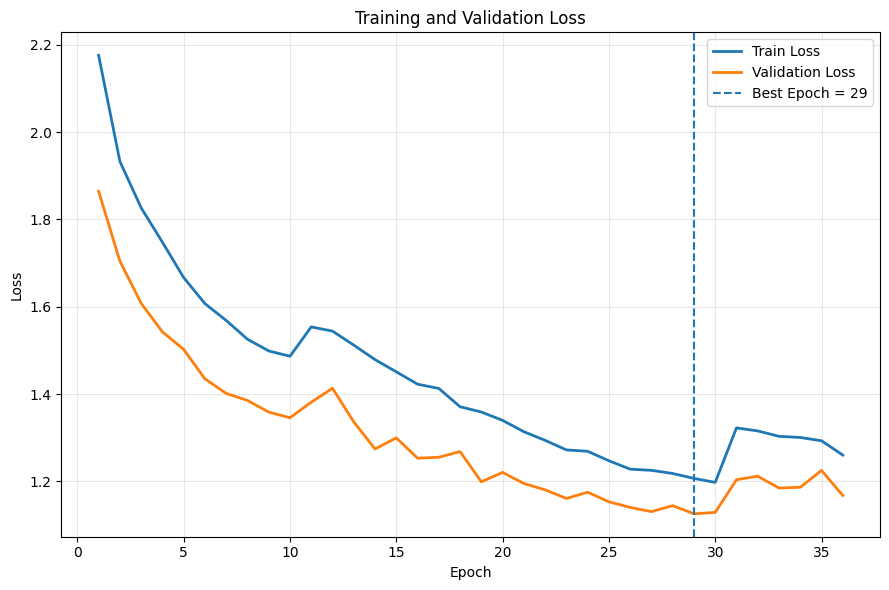

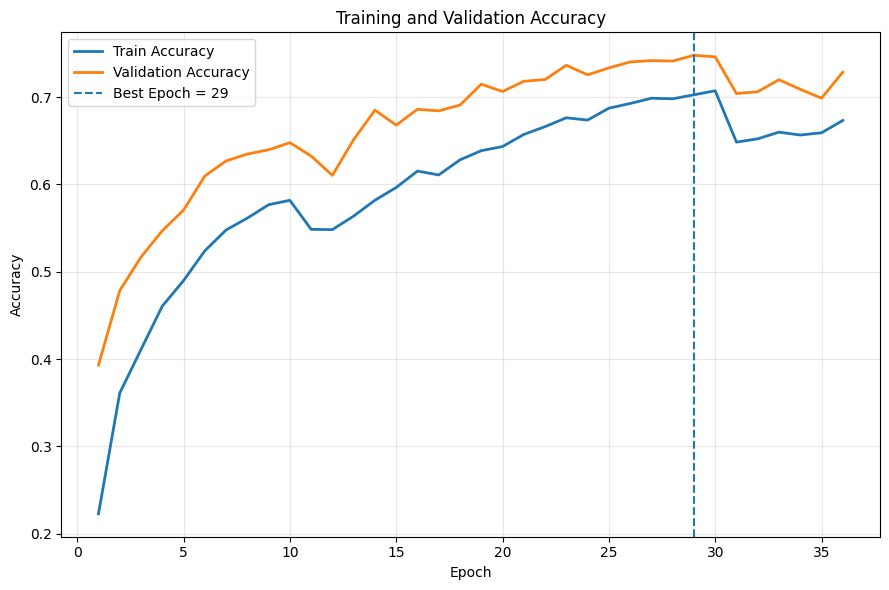

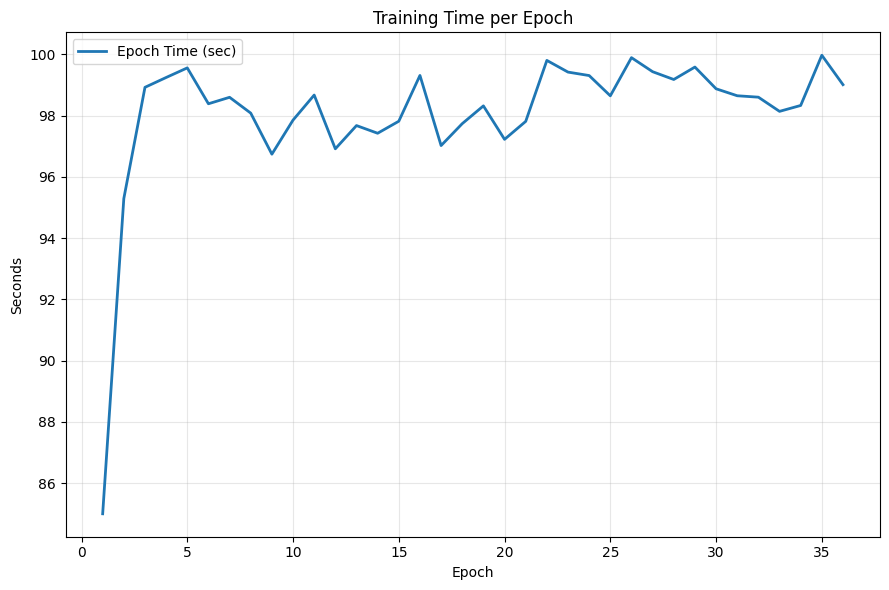

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from vitpol import ViT
import time
import matplotlib.pyplot as plt
import numpy as np


def main():
    model = ViT(
        img_size=224,
        patch_size=16,
        num_classes=10,
        in_channels=3,
        dim=512,
        depth=8,
        heads=8,
        mlp_dim=1024,
        dropout=0.1
    )

    batch_size = 64

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.RandAugment(num_ops=2, magnitude=7),
        transforms.ToTensor(),
        normalize,
        transforms.RandomErasing(p=0.25)
    ])

    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='train',
        size='320px',
        download=False,
        transform=transform_train
    )

    test_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='val',
        size='320px',
        download=False,
        transform=transform_test
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=4, pin_memory=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.03)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2
    )

    def train_epoch(model, loader, optimizer, criterion, device):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        return total_loss / len(loader), correct / total

    def test_epoch(model, loader, criterion, device):
        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        return total_loss / len(loader), correct / total

    epochs = 50

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    epoch_times = []

    best_test_loss = float('inf')
    best_epoch = 0

    patience = 7
    epochs_no_improve = 0

    log_file = open("training_log.txt", "w", encoding="utf-8")

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(test_loss)
        train_accs.append(train_acc)
        val_accs.append(test_acc)

        epoch_duration = time.time() - start_time
        epoch_times.append(epoch_duration)

        log_str = (f"Epoch {epoch+1}/{epochs} | "
                   f"Time: {epoch_duration:.2f}s | "
                   f"Train Acc: {train_acc:.4f}, Val Acc: {test_acc:.4f} | "
                   f"Train Loss: {train_loss:.4f}, Val Loss: {test_loss:.4f}\n")

        print(log_str, end="")
        log_file.write(log_str)
        log_file.flush()

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_vit_model.pth')
            print(f"---> New best model saved! Loss: {test_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), f'vit_epoch_{epoch+1}.pth')

    avg_time = sum(epoch_times) / len(epoch_times)
    total_time = sum(epoch_times)

    summary_str = (f"\n{'='*35}\n"
                   f"Training Complete!\n"
                   f"Total Time: {total_time:.2f}s ({total_time/60:.2f} min)\n"
                   f"Average Time per Epoch: {avg_time:.2f}s\n"
                   f"Best Validation Accuracy: {max(val_accs):.4f}\n"
                   f"Best Epoch: {best_epoch}\n"
                   f"{'='*35}")

    print(summary_str)
    log_file.write(summary_str + "\n")

    plt.style.use('default')
    epochs_range = np.arange(1, len(train_losses)+1)

    plt.figure(figsize=(9,6))
    plt.plot(epochs_range, train_losses, linewidth=2, label='Train Loss')
    plt.plot(epochs_range, val_losses, linewidth=2, label='Validation Loss')
    plt.axvline(best_epoch, linestyle='--', linewidth=1.5, label=f'Best Epoch = {best_epoch}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('research_loss_curve.png', dpi=300)
    plt.show()

    plt.figure(figsize=(9,6))
    plt.plot(epochs_range, train_accs, linewidth=2, label='Train Accuracy')
    plt.plot(epochs_range, val_accs, linewidth=2, label='Validation Accuracy')
    plt.axvline(best_epoch, linestyle='--', linewidth=1.5, label=f'Best Epoch = {best_epoch}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('research_accuracy_curve.png', dpi=300)
    plt.show()

    plt.figure(figsize=(9,6))
    plt.plot(epochs_range, epoch_times, linewidth=2, label='Epoch Time (sec)')
    plt.xlabel('Epoch')
    plt.ylabel('Seconds')
    plt.title('Training Time per Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('research_time_curve.png', dpi=300)
    plt.show()

    log_file.close()


if __name__ == '__main__':
    main()



ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

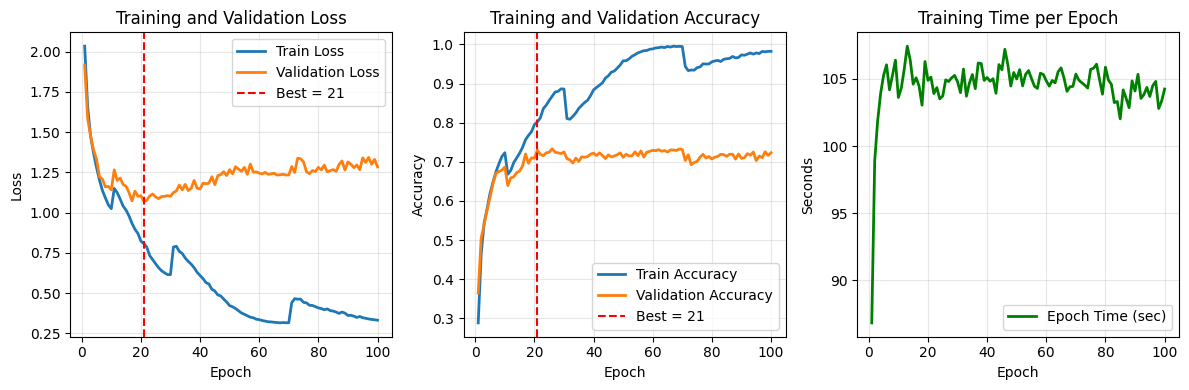

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from vitpol import ViT
import time
import matplotlib.pyplot as plt
import numpy as np


def main():
    model = ViT(
        img_size=224,
        patch_size=16,
        num_classes=10,
        in_channels=3,
        dim=512,
        depth=8,
        heads=8,
        mlp_dim=1024,
        dropout=0.1
    )

    batch_size = 64

    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        normalize,
    ])

    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='train',
        size='320px',
        download=False,
        transform=transform_train
    )

    test_dataset = torchvision.datasets.Imagenette(
        root='../data',
        split='val',
        size='320px',
        download=False,
        transform=transform_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=0.01
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2
    )

    def train_epoch(model, loader, optimizer, criterion, device):
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        avg_loss = total_loss / len(loader)
        accuracy = correct / total

        return avg_loss, accuracy

    def test_epoch(model, loader, criterion, device):
        model.eval()

        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)

                loss = criterion(outputs, labels)

                total_loss += loss.item()

                _, predicted = outputs.max(1)

                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_loss = total_loss / len(loader)
        accuracy = correct / total

        return avg_loss, accuracy

    epochs = 100

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    epoch_times = []

    best_test_loss = float('inf')
    best_epoch = 0

    patience = 7
    epochs_no_improve = 0

    log_file = open("training_log.txt", "w", encoding="utf-8")

    print(f"Starting training on {device}...\n")

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        test_loss, test_acc = test_epoch(
            model,
            test_loader,
            criterion,
            device
        )

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(test_loss)

        train_accs.append(train_acc)
        val_accs.append(test_acc)

        epoch_duration = time.time() - start_time
        epoch_times.append(epoch_duration)

        log_str = (
            f"Epoch {epoch+1}/{epochs} | "
            f"Time: {epoch_duration:.2f}s | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {test_acc:.4f} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {test_loss:.4f}\n"
        )

        print(log_str, end="")

        log_file.write(log_str)
        log_file.flush()

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0

            torch.save(model.state_dict(), 'best_vit_model.pth')

            print(f"New best model saved! Loss: {test_loss:.4f}")

        else:
            epochs_no_improve += 1

        # if epochs_no_improve >= patience:
        #     print(f"\nEarly stopping at epoch {epoch+1}")
        #     break

        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), f'vit_epoch_{epoch+1}.pth')

    avg_time = sum(epoch_times) / len(epoch_times)
    total_time = sum(epoch_times)

    summary_str = (
        f"\n{'='*45}\n"
        f"Training Complete!\n"
        f"Total Time: {total_time:.2f}s ({total_time/60:.2f} min)\n"
        f"Average Time per Epoch: {avg_time:.2f}s\n"
        f"Best Validation Accuracy: {max(val_accs):.4f}\n"
        f"Final Train Accuracy: {train_accs[-1]:.4f}\n"
        f"Final Val Accuracy: {val_accs[-1]:.4f}\n"
        f"Best Epoch: {best_epoch}\n"
        f"{'='*45}"
    )

    print(summary_str)

    log_file.write(summary_str + "\n")
    log_file.close()

    plt.style.use('default')

    epochs_range = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)

    plt.plot(
        epochs_range,
        train_losses,
        linewidth=2,
        label='Train Loss'
    )

    plt.plot(
        epochs_range,
        val_losses,
        linewidth=2,
        label='Validation Loss'
    )

    plt.axvline(
        best_epoch,
        linestyle='--',
        linewidth=1.5,
        color='red',
        label=f'Best = {best_epoch}'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)

    plt.plot(
        epochs_range,
        train_accs,
        linewidth=2,
        label='Train Accuracy'
    )

    plt.plot(
        epochs_range,
        val_accs,
        linewidth=2,
        label='Validation Accuracy'
    )

    plt.axvline(
        best_epoch,
        linestyle='--',
        linewidth=1.5,
        color='red',
        label=f'Best = {best_epoch}'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.title('Training and Validation Accuracy')

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)

    plt.plot(
        epochs_range,
        epoch_times,
        linewidth=2,
        color='green',
        label='Epoch Time (sec)'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Seconds')

    plt.title('Training Time per Epoch')

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig('training_curves.png', dpi=300)

    plt.show()


if __name__ == '__main__':

    
    main()